TEAMMATE STUDY GUIDE (Refer to Lecture 3 & TD1-PCA):
1. Why PCA? Our dataset has dozens of columns. PCA uses eigenvectors to compress these 
   columns into new "Principal Components" that capture the most variance (information).
2. The 85% Rule: We plot the cumulative variance curve to prove to the professor that 
   we only need 19 components to capture >85% of the data's behavior.
3. The 2D Plot: We plot the first 2 components to see if buyers and non-buyers form 
   distinct clusters. Because they overlap heavily, we prove the data is "non-linearly 
   separable," which justifies why we need a complex Random Forest instead of a simple model.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

DATASET_DIR = "/home/gq11/Documents/USTH/ML2/Project/dataset"

In [4]:
df = pd.read_parquet(os.path.join(DATASET_DIR,"train_cleaned.parquet"))
sample_df = df.sample(n=100000,random_state=42).copy()

print(f"Dataset Shape: {df.shape}")
print(f"Sample Shape: {sample_df.shape}")

Dataset Shape: (12715856, 48)
Sample Shape: (100000, 48)


In [5]:
feature_cols = (['age', 'renta'] + [c for c in df.columns if c.startswith('ind_') and c.endswith('ult1')])
sample_df[feature_cols] = sample_df[feature_cols].fillna(0)

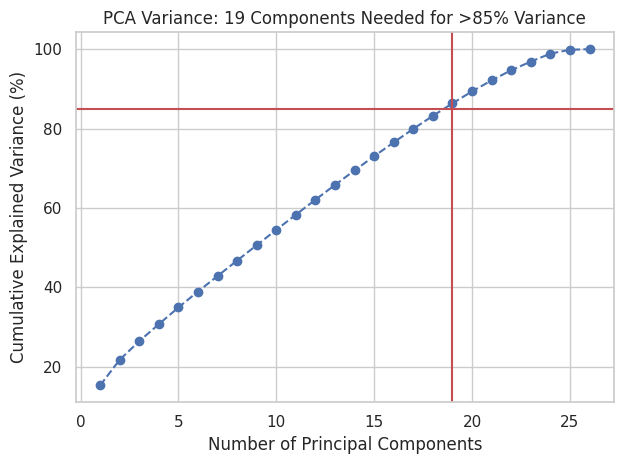

In [6]:
X_scaled = StandardScaler().fit_transform(sample_df[feature_cols])

# Plot 1: Variance Explained Curve
pca_full = PCA().fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100
components_85 = np.argmax(cumulative_variance >= 85.0) + 1

plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=85, color='r', linestyle='-')
plt.axvline(x=components_85, color='r', linestyle='-')
plt.title(f"PCA Variance: {components_85} Components Needed for >85% Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.tight_layout()
plt.show()


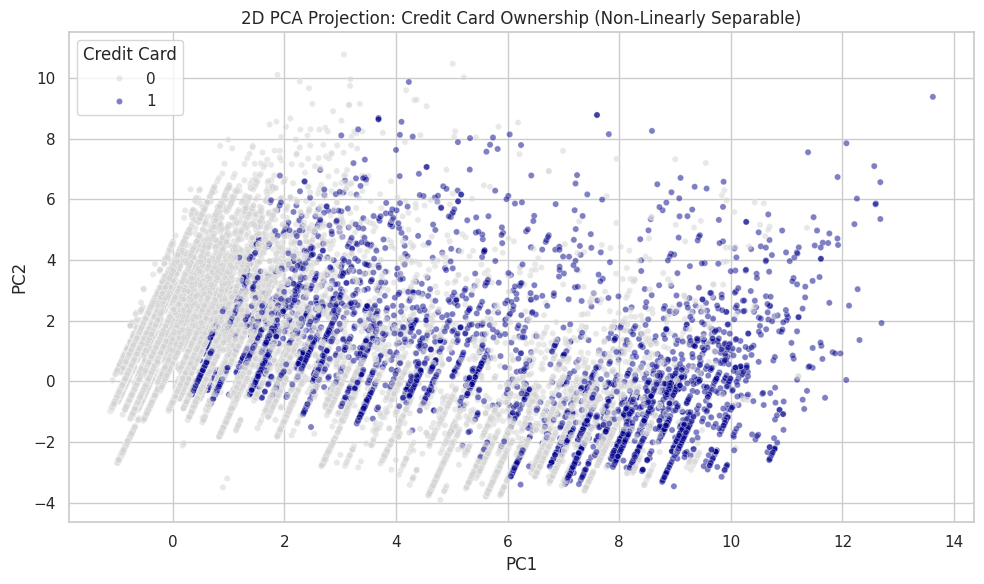

In [7]:
# Plot 2: 2D Subspace Projection
pca_2d = PCA(n_components=2).fit_transform(X_scaled)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=pca_2d[:, 0], y=pca_2d[:, 1], 
    hue=sample_df['ind_tjcr_fin_ult1'], 
    palette={0:'lightgrey', 1:'darkblue'}, 
    alpha=0.5, s=20
)
plt.title("2D PCA Projection: Credit Card Ownership (Non-Linearly Separable)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Credit Card")
plt.tight_layout()
plt.show()

overlap, nonlinear